<a href="https://colab.research.google.com/github/si-janenunes/CURSO-IA-CETAM-2026/blob/main/24_09_ModuloII_Pneumonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETAPA 1 — IMPORTAR AS BIBLIOTECAS

In [2]:
import os
import zipfile
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import files
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

# ETAPA 2 — FAZER UPLOAD DO ARQUIVO ZIP

In [3]:
# Ao executar esta parte no Google Colab, clique em
# "Escolher arquivos" e selecione o arquivo .zip do dataset.

# uploaded = files.upload() essa linha se vc quiser subir da maquina

# Pega automaticamente o nome do arquivo enviado.
# zip_path = list(uploaded.keys())[0]

# print("Imagens prontas para uso!")
#--------------------------------------------------

# Caminho do zip no seu Google Drive
zip_drive = '/content/drive/MyDrive/pneumonia.zip'



# Pasta de destino no disco rápido do Colab
pasta_destino = '/content/dataset'

# Descompacta rapidamente (leva apenas alguns segundos)
with zipfile.ZipFile(zip_drive, 'r') as zip_ref:
    zip_ref.extractall(pasta_destino)



print("Arquivo enviado:", zip_drive)

Arquivo enviado: /content/drive/MyDrive/pneumonia.zip


# ETAPA 3 — DESCOMPACTAR O DATASET

In [4]:
pasta_extraida = "/content/dataset_original"

# Apaga a pasta antiga, caso o código seja executado novamente.

if os.path.exists(pasta_extraida):
    shutil.rmtree(pasta_extraida)

os.makedirs(pasta_extraida)

with zipfile.ZipFile(zip_drive, "r") as zip_ref:
    zip_ref.extractall(pasta_extraida)

print("Dataset descompactado!")
print("Conteúdo inicial:", os.listdir(pasta_extraida)[:10])

Dataset descompactado!
Conteúdo inicial: ['xray_dataset_covid19']


# ETAPA 4 — LOCALIZAR AS IMAGENS DE PULMÕES NORMAIS E AFETADOS

In [5]:
imagens_pulmoesnormais = []
imagens_pulmoesafetados = []

for raiz, pastas, arquivos in os.walk(pasta_extraida):
    # Determina a categoria com base no nome do diretório
    categoria = os.path.basename(raiz).lower()

    for arquivo in arquivos:
        # Constrói o caminho completo do arquivo
        caminho_completo_arquivo = os.path.join(raiz, arquivo)

        # Ignora arquivos que não são imagens
        if not caminho_completo_arquivo.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        # Classifica as imagens com base no nome do diretório pai
        if "normal" in categoria:
            imagens_pulmoesnormais.append(caminho_completo_arquivo)
        elif "pneumonia" in categoria:
            imagens_pulmoesafetados.append(caminho_completo_arquivo)

print("Total de pulmões normais encontrados:", len(imagens_pulmoesnormais))
print("Total de pulmões afetados encontrados:", len(imagens_pulmoesafetados))

Total de pulmões normais encontrados: 94
Total de pulmões afetados encontrados: 94


# ETAPA 5 — EMBARALHAR AS IMAGENS

In [6]:
# Usamos uma semente fixa para que a divisão possa ser
# reproduzida novamente.

random.seed(123)

random.shuffle(imagens_pulmoesnormais)
random.shuffle(imagens_pulmoesafetados)

# ETAPA 6 — CRIAR TREINO, VALIDAÇÃO E TESTE

In [7]:
# Divisão utilizada:
#
# 70% -> Treino
# 15% -> Validação
# 15% -> Teste
#
# A separação é feita individualmente para cada classe.
# Assim mantemos gatos e cachorros distribuídos entre
# os três conjuntos.

def dividir_dados(lista):

    total = len(lista)

    fim_treino = int(total * 0.70)
    fim_validacao = int(total * 0.85)

    treino = lista[:fim_treino]
    validacao = lista[fim_treino:fim_validacao]
    teste = lista[fim_validacao:]

    return treino, validacao, teste


pulmoesnormais_treino, pulmoesnormais_val, pulmoesnormais_teste = dividir_dados(imagens_pulmoesnormais)
pulmoesafetados_treino, pulmoesafetados_val, pulmoesafetados_teste = dividir_dados(imagens_pulmoesafetados)


# ETAPA 7 — CRIAR A ESTRUTURA DE PASTAS

In [8]:
# dataset_final/
#
# ├── train/
# │   ├── pulmoesnormais/
# │   └── pulmoesafetados/
# │
# ├── validation/
# │   ├── pulmoesnormais/
# │   └── pulmoesafetados/
# │
# └── test/
#     ├── pulmoesnormais/
#     └── pulmoesafetados/

dataset_final = "/content/dataset_final"

if os.path.exists(dataset_final):
    shutil.rmtree(dataset_final)

pastas = [
    "train/pulmoesnormais",
    "train/pulmoesafetados",
    "validation/pulmoesnormais",
    "validation/pulmoesafetados",
    "test/pulmoesnormais",
    "test/pulmoesafetados"
]

for pasta in pastas:
    os.makedirs(os.path.join(dataset_final, pasta), exist_ok=True)


# ETAPA 8 — COPIAR AS IMAGENS PARA AS PASTAS

In [9]:
def copiar_imagens(lista, destino):

    for caminho in lista:
        shutil.copy2(caminho, destino)


copiar_imagens(pulmoesnormais_treino, dataset_final + "/train/pulmoesnormais")
copiar_imagens(pulmoesafetados_treino, dataset_final + "/train/pulmoesafetados")

copiar_imagens(pulmoesnormais_val, dataset_final + "/validation/pulmoesnormais")
copiar_imagens(pulmoesafetados_val, dataset_final + "/validation/pulmoesafetados")

copiar_imagens(pulmoesnormais_teste, dataset_final + "/test/pulmoesnormais")
copiar_imagens(pulmoesafetados_teste, dataset_final + "/test/pulmoesafetados")

print("Separação concluída!")


Separação concluída!


# ETAPA 9 — CONFERIR A QUANTIDADE DE IMAGENS

In [10]:
print("\nTREINO")
print("Pulmoes Normais:", len(os.listdir(dataset_final + "/train/pulmoesnormais")))
print("Pulmoes Afetados:", len(os.listdir(dataset_final + "/train/pulmoesafetados")))

print("\nVALIDAÇÃO")
print("Pulmoes Normais:", len(os.listdir(dataset_final + "/validation/pulmoesnormais")))
print("Pulmoes Afetados:", len(os.listdir(dataset_final + "/validation/pulmoesafetados")))

print("\nTESTE")
print("Pulmoes Normais:", len(os.listdir(dataset_final + "/test/pulmoesnormais")))
print("Pulmoes Afetados:", len(os.listdir(dataset_final + "/test/pulmoesafetados")))


TREINO
Pulmoes Normais: 65
Pulmoes Afetados: 65

VALIDAÇÃO
Pulmoes Normais: 14
Pulmoes Afetados: 14

TESTE
Pulmoes Normais: 15
Pulmoes Afetados: 15


# ETAPA 10 — CARREGAR OS DATASETS COM O KERAS

In [11]:
# Todas as imagens serão redimensionadas para 150 x 150.
# batch_size = 32 significa que o modelo trabalha com
# grupos de 32 imagens por vez.

img_size = (150, 150)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_final + "/train",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_final + "/validation",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_final + "/test",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names

print("\nClasses encontradas:", class_names)

Found 130 files belonging to 2 classes.
Found 28 files belonging to 2 classes.
Found 30 files belonging to 2 classes.

Classes encontradas: ['pulmoesafetados', 'pulmoesnormais']


# ETAPA 11 — VISUALIZAR ALGUMAS IMAGENS

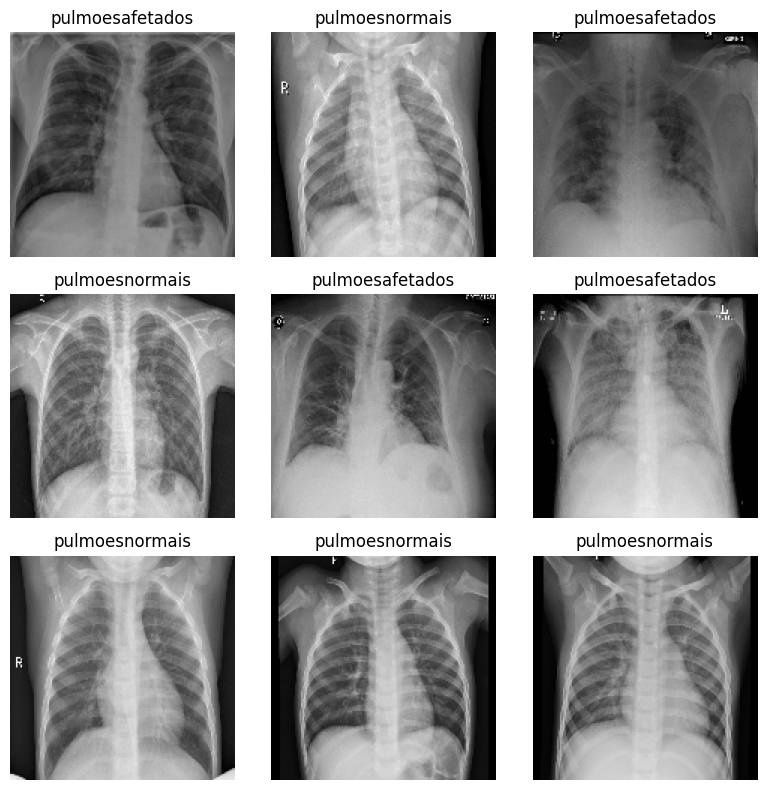

In [12]:
plt.figure(figsize=(8, 8))

for imagens, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(imagens[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

# ETAPA 12 — CRIAR A REDE NEURAL CONVOLUCIONAL (CNN)

In [13]:
# Rescaling:
# transforma pixels de 0-255 para valores entre 0-1.
#
# Conv2D:
# procura características nas imagens.
#
# MaxPooling2D:
# reduz o tamanho das informações.
#
# Flatten:
# transforma os mapas de características em um vetor.
#
# Dense:
# realiza a classificação.
#
# Sigmoid:
# usada porque temos duas classes: gatos e cachorros.
#++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# model = models.Sequential([

    # layers.Input(shape=(150, 150, 3)),

    # layers.Rescaling(1./255),

    # layers.Conv2D(32, (3, 3), activation="relu"),
    # layers.MaxPooling2D(2, 2),

    # layers.Conv2D(64, (3, 3), activation="relu"),
    # layers.MaxPooling2D(2, 2),

    # layers.Conv2D(128, (3, 3), activation="relu"),
    # layers.MaxPooling2D(2, 2),

    # layers.Flatten(),

    # layers.Dense(128, activation="relu"),

    # layers.Dense(1, activation="sigmoid")
# ])

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# 1. Criamos a sequência de transformações aleatórias
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),       # Inverte a imagem da esquerda pra direita
    layers.RandomRotation(0.1),            # Rotaciona levemente a foto (até 10%)
    layers.RandomZoom(0.1),                # Aplica zoom de até 10%
    layers.RandomContrast(0.1)             # Altera ligeiramente o contraste
], name="data_augmentation")

# 2. Inserimos o bloco no início da nossa CNN
model = models.Sequential([

    layers.Input(shape=(150, 150, 3)),

    # AQUI ENTRA A DATA AUGMENTATION (Só é ativa durante o model.fit)
    data_augmentation,

    # Normalização de pixels (0-255 para 0-1)
    layers.Rescaling(1./255),

    # Camadas Convolucionais
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    # Camadas Densas
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# ETAPA 13 — COMPILAR O MODELO

In [14]:
# Adam:
# ajusta os pesos da rede.
#
# binary_crossentropy:
# mede o erro em uma classificação com duas classes.
#
# accuracy:
# mede a porcentagem de acertos.

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)



# ETAPA 14 — MOSTRAR A ESTRUTURA DA CNN

In [15]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

# ETAPA 15 — CRIAR O CHECKPOINT

In [16]:
# O checkpoint salva o modelo que apresentar o MENOR
# erro de validação (val_loss).

checkpoint = ModelCheckpoint(
    "/content/melhor_modelo.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)


# ETAPA 16 — TREINAR A CNN

In [17]:
# Uma época significa uma passagem completa pelos dados
# de treinamento.
#
# O conjunto de teste NÃO é utilizado nesta etapa.

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint]
)



Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4563 - loss: 1.1583
Epoch 1: val_loss improved from None to 0.68262, saving model to /content/melhor_modelo.keras

Epoch 1: finished saving model to /content/melhor_modelo.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 442ms/step - accuracy: 0.4846 - loss: 1.1176 - val_accuracy: 0.6071 - val_loss: 0.6826
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.5905 - loss: 0.6826
Epoch 2: val_loss improved from 0.68262 to 0.66437, saving model to /content/melhor_modelo.keras

Epoch 2: finished saving model to /content/melhor_modelo.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 666ms/step - accuracy: 0.5462 - loss: 0.6815 - val_accuracy: 0.5000 - val_loss: 0.6644
Epoch 3/50
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.5293 - loss: 0.6659
Epoch 3: val_loss improved from 0.66437 to 0.65752, saving model to /content/melhor_modelo.keras

Epoch 3: finished saving model to /content/melhor_modelo.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 491ms/step 

# ETAPA 17 — GRÁFICO DO LOSS

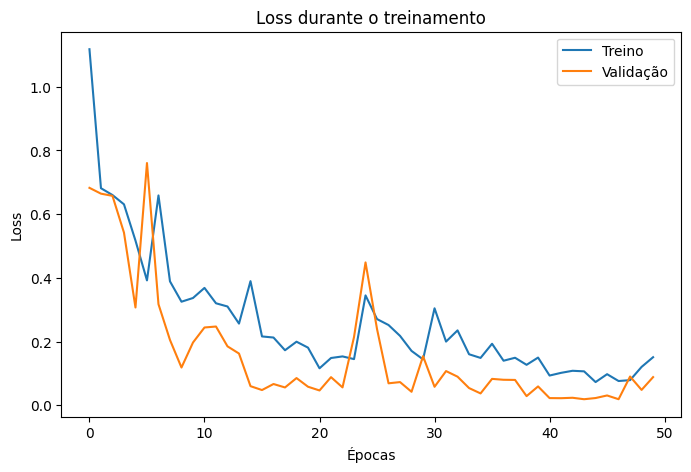

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validação")

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Loss durante o treinamento")
plt.legend()

plt.show()

# ETAPA 18 — GRÁFICO DA ACURÁCIA

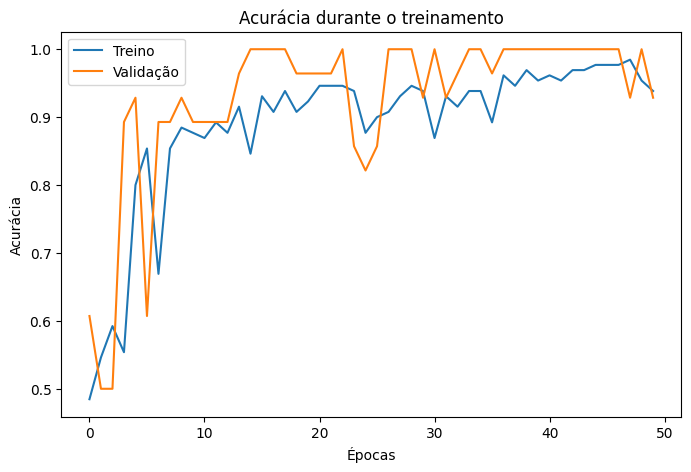

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validação")

plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.title("Acurácia durante o treinamento")
plt.legend()

plt.show()

# ETAPA 19 — IDENTIFICAR A MELHOR ÉPOCA

In [20]:
melhor_epoca = np.argmin(history.history["val_loss"]) + 1
melhor_val_loss = np.min(history.history["val_loss"])

print("Melhor época:", melhor_epoca)
print("Menor val_loss:", melhor_val_loss)


Melhor época: 44
Menor val_loss: 0.019311144948005676


# ETAPA 20 — CARREGAR O MELHOR MODELO

In [21]:
melhor_modelo = load_model("/content/melhor_modelo.keras")

print("Melhor modelo carregado!")

Melhor modelo carregado!


# ETAPA 21 — AVALIAÇÃO FINAL COM O CONJUNTO DE TESTE

In [22]:
#Somente agora usamos o conjunto de teste.
# Essas imagens não foram utilizadas para treinar o modelo
# nem para escolher a melhor época.

test_loss, test_accuracy = melhor_modelo.evaluate(test_ds)

print("\nRESULTADO FINAL")
print("Loss no teste:", test_loss)
print("Acurácia no teste:", test_accuracy)
print("Acurácia no teste (%):", test_accuracy * 100)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step - accuracy: 0.9333 - loss: 0.1060

RESULTADO FINAL
Loss no teste: 0.10601765662431717
Acurácia no teste: 0.9333333373069763
Acurácia no teste (%): 93.33333373069763


# ETAPA 22 — FAZER PREVISÕES NO CONJUNTO DE TESTE

In [23]:
# A sigmoid produz valores entre 0 e 1.
#
# Valor < 0.5 -> classe 0
# Valor >= 0.5 -> classe 1

imagens_lista = []
reais_lista = []
previstos_lista = []
probabilidades_lista = []

for imagens, labels in test_ds:

    probabilidades = melhor_modelo.predict(imagens, verbose=0).flatten()

    previsoes = (probabilidades >= 0.5).astype("int32")

    imagens_lista.extend(imagens.numpy())
    reais_lista.extend(labels.numpy())
    previstos_lista.extend(previsoes)
    probabilidades_lista.extend(probabilidades)

print("Previsões realizadas!")


Previsões realizadas!


# ETAPA 23 — LOCALIZAR OS ACERTOS E OS ERROS

In [24]:
acertos = []
erros = []

for i in range(len(reais_lista)):

    if reais_lista[i] == previstos_lista[i]:
        acertos.append(i)

    else:
        erros.append(i)

print("Quantidade de acertos:", len(acertos))
print("Quantidade de erros:", len(erros))

Quantidade de acertos: 28
Quantidade de erros: 2


# ETAPA 24 — MOSTRAR 5 ACERTOS

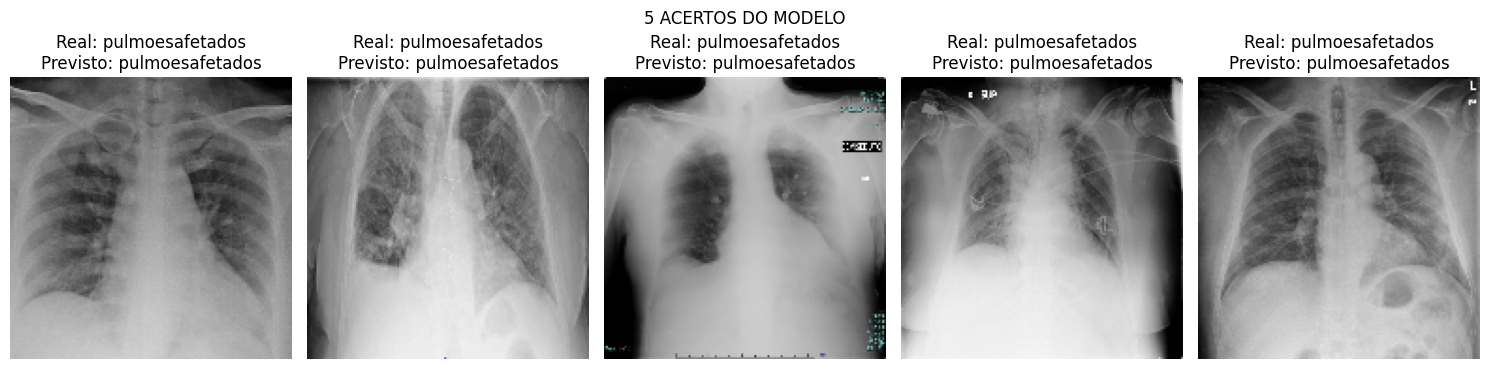

In [25]:
plt.figure(figsize=(15, 4))

for posicao, i in enumerate(acertos[:5]):

    plt.subplot(1, 5, posicao + 1)

    plt.imshow(imagens_lista[i].astype("uint8"))

    real = class_names[int(reais_lista[i])]
    previsto = class_names[int(previstos_lista[i])]

    plt.title(
        f"Real: {real}\n"
        f"Previsto: {previsto}"
    )

    plt.axis("off")

plt.suptitle("5 ACERTOS DO MODELO")
plt.tight_layout()
plt.show()

# ETAPA 25 — MOSTRAR 5 ERROS

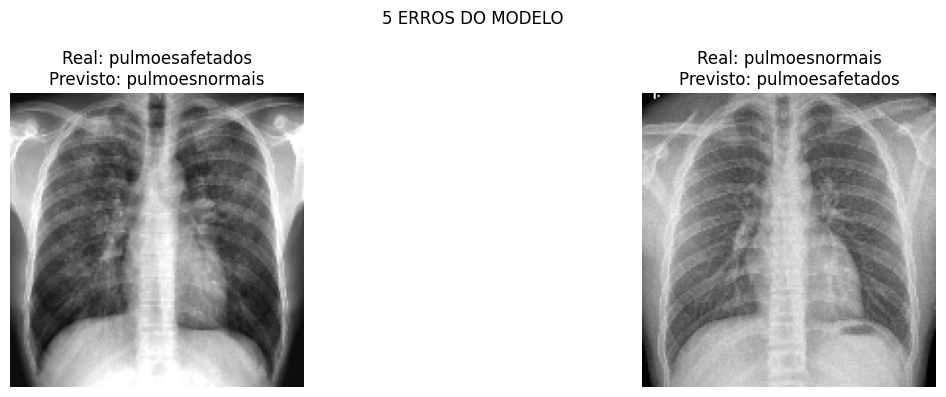

In [26]:
if len(erros) > 0:

    quantidade = min(5, len(erros))

    plt.figure(figsize=(15, 4))

    for posicao, i in enumerate(erros[:quantidade]):

        plt.subplot(1, quantidade, posicao + 1)

        plt.imshow(imagens_lista[i].astype("uint8"))

        real = class_names[int(reais_lista[i])]
        previsto = class_names[int(previstos_lista[i])]

        plt.title(
            f"Real: {real}\n"
            f"Previsto: {previsto}"
        )

        plt.axis("off")

    plt.suptitle("5 ERROS DO MODELO")
    plt.tight_layout()
    plt.show()

else:
    print("O modelo não apresentou erros no conjunto de teste.")


# FIM DA PIPELINE

RESUMO:
#
# 1. Upload do ZIP
# 2. Descompactação
# 3. Identificação de gatos e cachorros
# 4. Separação:
#       70% treino
#       15% validação
#       15% teste
# 5. Carregamento das imagens
# 6. Criação da CNN
# 7. Treinamento
# 8. Checkpoint pelo menor val_loss
# 9. Gráficos de loss e acurácia
# 10. Carregamento do melhor modelo
# 11. Avaliação no conjunto de teste
# 12. Exibição de 5 acertos
# 13. Exibição de 5 erros